In [26]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem import PorterStemmer, LancasterStemmer
import nltk
from SOM import SOM
from help_functions import visualize_u_matrix, visualize_label_matrix, visualize_u_matrix_extended


In [2]:
df = pd.read_csv('../data/Time_magazine.csv')
y = df['file'].to_numpy()
X = df.drop(['file'], axis=1).to_numpy()

In [3]:
stemmer = LancasterStemmer()

def english_tokenizer(text):  
    tokens = nltk.word_tokenize(text)
    stems = [stemmer.stem(t) for t in tokens if t.isalnum()]
    return stems

# TF-IDF transformation on the text with filtering on high and low frequency terms
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.9,  
    min_df=0.01, 
)

In [4]:
X_sparse = tfidf_vectorizer.fit_transform(X.ravel())
X_tfidf = X_sparse.toarray()

In [5]:
X_tfidf.shape

(420, 5000)

In [6]:
som = SOM(10,10,5000)

In [11]:
som.train_online(X_tfidf, y, 50)

Epoch 0/50 complete. Sigma: 4.5832, Lr: 0.4583, QE: 0.9985, TE: 0.1119, Purity: 0.0976
Epoch 10/50 complete. Sigma: 4.5376, Lr: 0.4538, QE: 1.0015, TE: 0.2595, Purity: 0.0476
Epoch 20/50 complete. Sigma: 4.4924, Lr: 0.4492, QE: 1.0078, TE: 0.0452, Purity: 0.0690
Epoch 30/50 complete. Sigma: 4.4477, Lr: 0.4448, QE: 1.0050, TE: 0.0500, Purity: 0.0833
Epoch 40/50 complete. Sigma: 4.4034, Lr: 0.4403, QE: 1.0038, TE: 0.3810, Purity: 0.0571


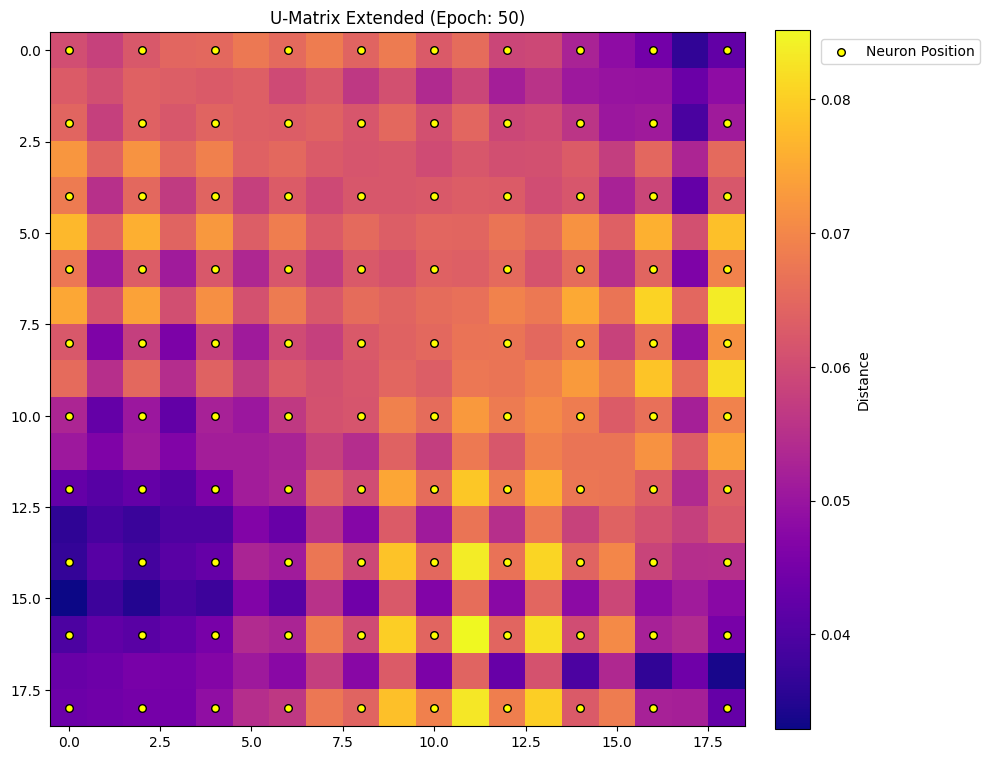

In [27]:
visualize_u_matrix_extended(som, 50)

In [21]:
terms = tfidf_vectorizer.get_feature_names_out()

In [37]:
weight = som.get_weight_of_node((0,0))

top_indices = weight.argsort()[-10:][::-1]
top_words = [terms[ind] for ind in top_indices]
print(top_words)

['congo', 'congolese', 'as', 'is', 'south', 'african', 'motto', 'his', 'have', 'he']


In [33]:
weight = som.get_weight_of_node((8,7))

top_indices = weight.argsort()[-10:][::-1]
top_words = [terms[ind] for ind in top_indices]
print(top_words)

['her', 'miss', 'she', 'car', 'driver', 'round', 'pakistan', 'court', 'test', 'at']


In [34]:
weight = som.get_weight_of_node((9,7))

top_indices = weight.argsort()[-10:][::-1]
top_words = [terms[ind] for ind in top_indices]
print(top_words)

['her', 'miss', 'she', 'car', 'driver', 'round', 'court', 'test', 'soviet', 'pakistan']


In [50]:
X[100]

array(['COMMUNISTS ON THE ANNIVERSARY AFTER STALIN\'S 70TH BIRTHDAY IN 1949, IT TOOK PRAVDA 22 MONTHS TO PRINT ALL THE NAMES OF HIS WELL-WISHERS. LAST WEEK, ON THE TENTH ANNIVERSARY OF THE TYRANT\'S DEATH, THERE WAS NOT A SINGLE MENTION BY PRESS OR RADIO OF THE MAN NIKITA KHRUSHCHEV ONCE FULSOMELY PRAISED AS " OUR GREAT LEADER, OUR FRIEND AND FATHER, THE GREATEST MAN OF OUR EPOCH. " IN ALL OF MOSCOW\'S MILLIONS, ONLY A SINGLE ANONYMOUS SOUL DARED TO PAY RESPECTS WITH THREE RUBLES WORTH OF YELLOW MIMOSA ON STALIN\'S BLACK MARBLE SLAB NEAR THE KREMLIN WALL INY ALBANIA, SEIZING ANY EXCUSE TO DEFY THE SOVIETS, WAS GUSHING STALIN\'S PRAISE. ALL OVER THE COUNTRY, MONUMENTS TO THE DEAD DICTATOR WERE HUNG WITH GARLANDS OF FLOWERS; TIRANA NEWSPAPERS PUBLISHED HIS PICTURE AND BABBLED THEIR " LOVE AND PROFOUND RESPECT FOR HIS TEACHINGS. " RED CHINA MIGHT ALSO HAVE BEEN EXPECTED TO USE THE OCCASION TO GLORIFY STALIN\'S MEMORY, BUT REMEMBERING THE DICTATOR\'S OPEN DISTRUST OF HIS ASIAN COMRADES, PE

In [52]:
top_indices = X_tfidf[100].argsort()[-10:][::-1]
top_words = [terms[ind] for ind in top_indices]
print(top_words)

['stalin', 'peking', 'moscow', 'khrushchev', 'red', 'anniversary', 'mao', 'occasion', 'wall', 'sino']
